# R3D-18 Shoplifting Classification

This notebook fine-tunes a pretrained **R3D-18** (3D ResNet-18, Kinetics-400) from `torchvision` for binary shoplifting detection.

# Import Libraries

In [1]:
import os
import shutil
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models.video as video_models
from torchvision.models.video import R3D_18_Weights


# Read Data

In [2]:
src_dir = "/kaggle/input/datasets/omarelg/shoplifting-videos-dataset/Shop DataSet"
dst_dir = "/kaggle/working/Shop DataSet"

if not os.path.exists(dst_dir):
    shutil.copytree(src_dir, dst_dir)

print("Copied to writable directory:", dst_dir)

Copied to writable directory: /kaggle/working/Shop DataSet


In [3]:
DATASET_DIR = "/kaggle/working/Shop DataSet"

non_shop_lifters_dir = os.path.join(DATASET_DIR, "non shop lifters")
shop_lifters_dir = os.path.join(DATASET_DIR, "shop lifters")

In [4]:
CLASS_NAMES  = ["non shop lifters", "shop lifters"]
CLASS_TO_LABEL = {"non shop lifters": 0, "shop lifters": 1}

# R3D-18 was pretrained with 16-frame clips at 112x112
SEQ_LEN    = 16
IMG_SIZE   = 112
BATCH_SIZE = 4
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
def delete_all_suffix_1_files(folder_path):
    print(f"\nChecking folder: {folder_path}")
    video_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")]
    to_delete   = [f for f in video_files if re.search(r"_1\.mp4$", f, re.IGNORECASE)]
    print(f"Files to delete: {len(to_delete)}")
    for f in to_delete:
        file_path = os.path.join(folder_path, f)
        try:
            os.remove(file_path)
            print(f"Deleted: {f}")
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")

delete_all_suffix_1_files(non_shop_lifters_dir)
delete_all_suffix_1_files(shop_lifters_dir)


Checking folder: /kaggle/working/Shop DataSet/non shop lifters
Files to delete: 220
Deleted: shop_lifter_n_116_1.mp4
Deleted: shop_lifter_n_133_1.mp4
Deleted: shop_lifter_n_110_1.mp4
Deleted: shop_lifter_n_36_1.mp4
Deleted: shop_lifter_n_163_1.mp4
Deleted: shop_lifter_n_217_1.mp4
Deleted: shop_lifter_n_121_1.mp4
Deleted: shop_lifter_n_30_1.mp4
Deleted: shop_lifter_n_208_1.mp4
Deleted: shop_lifter_n_28_1.mp4
Deleted: shop_lifter_n_188_1.mp4
Deleted: shop_lifter_n_59_1.mp4
Deleted: shop_lifter_n_205_1.mp4
Deleted: shop_lifter_n_193_1.mp4
Deleted: shop_lifter_n_5_1.mp4
Deleted: shop_lifter_n_190_1.mp4
Deleted: shop_lifter_n_164_1.mp4
Deleted: shop_lifter_n_156_1.mp4
Deleted: shop_lifter_n_20_1.mp4
Deleted: shop_lifter_n_186_1.mp4
Deleted: shop_lifter_n_144_1.mp4
Deleted: shop_lifter_n_183_1.mp4
Deleted: shop_lifter_n_138_1.mp4
Deleted: shop_lifter_n_216_1.mp4
Deleted: shop_lifter_n_111_1.mp4
Deleted: shop_lifter_n_203_1.mp4
Deleted: shop_lifter_n_86_1.mp4
Deleted: shop_lifter_n_73_1.mp4


In [6]:
def count_videos(folder_path):
    return len([f for f in os.listdir(folder_path) if f.lower().endswith(".mp4")])

non_count  = count_videos(non_shop_lifters_dir)
shop_count = count_videos(shop_lifters_dir)
print("non shop lifters videos:", non_count)
print("shop lifters videos    :", shop_count)
print("Total videos           :", non_count + shop_count)

non shop lifters videos: 311
shop lifters videos    : 319
Total videos           : 630


# Understand Data

In [7]:
def collect_video_metadata(dataset_dir, class_names):
    records = []
    for cls in class_names:
        class_dir = os.path.join(dataset_dir, cls)
        if not os.path.exists(class_dir):
            print(f"Folder not found: {class_dir}")
            continue
        for file_name in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file_name)
            if not os.path.isfile(file_path):
                continue
            cap = cv2.VideoCapture(file_path)
            frames   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps      = cap.get(cv2.CAP_PROP_FPS)
            width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            duration = frames / fps if fps and fps > 0 else 0
            records.append({
                "class": cls, "label": CLASS_TO_LABEL[cls],
                "file": file_name, "path": file_path,
                "frames": frames, "fps": fps,
                "width": width, "height": height, "duration_sec": duration
            })
            cap.release()
    return pd.DataFrame(records)

df = collect_video_metadata(DATASET_DIR, CLASS_NAMES)
print(df.shape)
df.head()


(630, 9)


,class,label,file,path,frames,fps,width,height,duration_sec
0,non shop lifters,0,videppppsss_46.mp4,/kaggle/working/Shop DataSet/non shop lifters/...,398,24.83,704,576,16.028997
1,non shop lifters,0,videppppsss_49.mp4,/kaggle/working/Shop DataSet/non shop lifters/...,298,24.83,704,576,12.001611
2,non shop lifters,0,videppppsss_21.mp4,/kaggle/working/Shop DataSet/non shop lifters/...,323,24.83,704,576,13.008458
3,non shop lifters,0,shop_lifter_n_204.mp4,/kaggle/working/Shop DataSet/non shop lifters/...,400,25.00,704,576,16.000000
4,non shop lifters,0,shop_lifter_n_210.mp4,/kaggle/working/Shop DataSet/non shop lifters/...,500,25.00,704,576,20.000000


In [8]:
print(df["class"].value_counts())
print()
print(df.describe(include="all"))

class
shop lifters        319
non shop lifters    311
Name: count, dtype: int64

               class       label               file  \
count            630  630.000000                630   
unique             2         NaN                575   
top     shop lifters         NaN  videppppsss_0.mp4   
freq             319         NaN                  2   
mean             NaN    0.506349                NaN   
std              NaN    0.500357                NaN   
min              NaN    0.000000                NaN   
25%              NaN    0.000000                NaN   
50%              NaN    1.000000                NaN   
75%              NaN    1.000000                NaN   
max              NaN    1.000000                NaN   

                                                     path       frames  \
count                                                 630   630.000000   
unique                                                630          NaN   
top     /kaggle/working/Shop DataSet

# Visualization

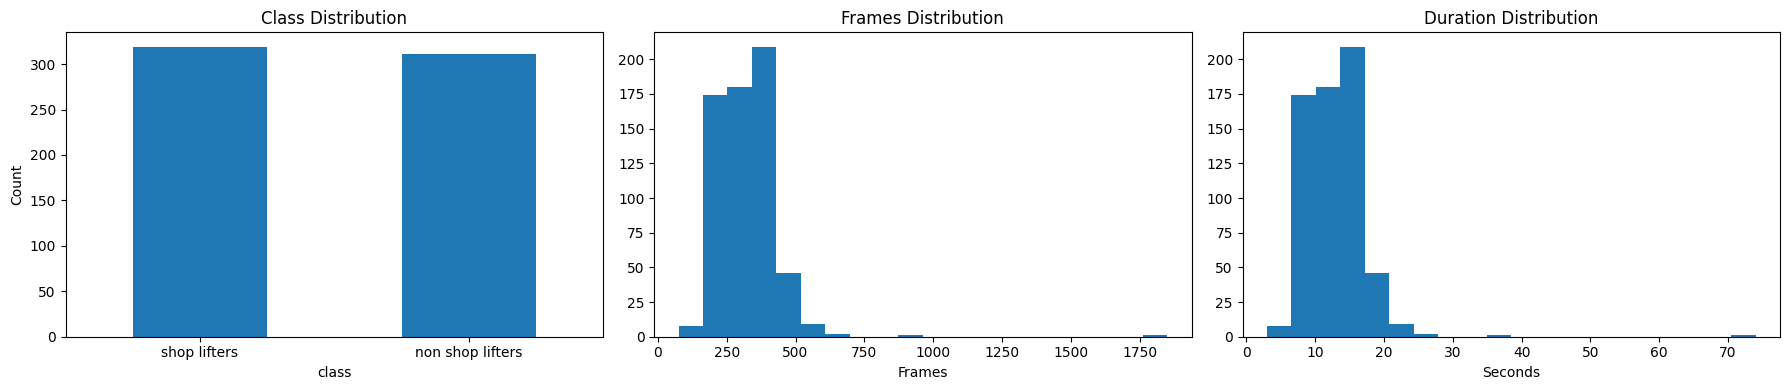

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
df["class"].value_counts().plot(kind="bar", ax=axes[0], title="Class Distribution")
axes[0].set_ylabel("Count"); axes[0].tick_params(axis="x", rotation=0)
axes[1].hist(df["frames"], bins=20); axes[1].set_title("Frames Distribution"); axes[1].set_xlabel("Frames")
axes[2].hist(df["duration_sec"], bins=20); axes[2].set_title("Duration Distribution"); axes[2].set_xlabel("Seconds")
plt.tight_layout(); plt.show()

In [10]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label"])
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (441, 9)
Val  : (94, 9)
Test : (95, 9)


# Preprocessing

In [11]:
def uniform_frame_sampling(video_path, seq_len=16, img_size=112):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return np.zeros((seq_len, img_size, img_size, 3), dtype=np.float32)
    indices = np.linspace(0, total - 1, seq_len).astype(int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ok, frame = cap.read()
        if not ok:
            frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
        frames.append(frame)
    cap.release()
    return np.array(frames, dtype=np.float32)

In [12]:
def augment_video_frames(frames):
    aug = frames.copy()
    if random.random() < 0.5:
        aug = np.array([cv2.flip(f, 1) for f in aug])
    if random.random() < 0.5:
        factor = random.uniform(0.8, 1.2)
        aug = np.clip(aug * factor, 0, 255)
    if random.random() < 0.3:
        angle = random.uniform(-10, 10)
        h, w  = aug[0].shape[:2]
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
        aug = np.array([cv2.warpAffine(f, M, (w, h), borderMode=cv2.BORDER_REFLECT_101) for f in aug])
    return aug.astype(np.float32)

In [13]:
# R3D-18 Kinetics-400 normalisation values
R3D_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32)
R3D_STD  = np.array([0.22803, 0.22145,  0.216989], dtype=np.float32)

def preprocess_video(video_path, seq_len=16, img_size=112, augment=False):
    frames = uniform_frame_sampling(video_path, seq_len=seq_len, img_size=img_size)
    if augment:
        frames = augment_video_frames(frames)
    frames = frames / 255.0
    frames = (frames - R3D_MEAN) / R3D_STD          # normalise
    # R3D expects (C, T, H, W)
    frames = frames.transpose(3, 0, 1, 2)           # (H,W,C) -> (C,T,H,W)
    return frames.astype(np.float32)

In [14]:
class ShopliftingDataset(Dataset):
    def __init__(self, df, seq_len=16, img_size=112, augment=False):
        self.df       = df.reset_index(drop=True).copy()
        self.seq_len  = seq_len
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        video = preprocess_video(row["path"], seq_len=self.seq_len,
                                 img_size=self.img_size, augment=self.augment)
        label = np.float32(row["label"])
        return torch.tensor(video), torch.tensor(label)

In [15]:
train_ds = ShopliftingDataset(train_df, seq_len=SEQ_LEN, img_size=IMG_SIZE, augment=True)
val_ds   = ShopliftingDataset(val_df,   seq_len=SEQ_LEN, img_size=IMG_SIZE, augment=False)
test_ds  = ShopliftingDataset(test_df,  seq_len=SEQ_LEN, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

# sanity check
xb, yb = next(iter(train_loader))
print("X shape:", xb.shape)   # (B, C, T, H, W)
print("y shape:", yb.shape)

Train batches: 111
Val batches  : 24
Test batches : 24
X shape: torch.Size([4, 3, 16, 112, 112])
y shape: torch.Size([4])


# Model

In [16]:
def build_r3d_model(num_classes=1, freeze_backbone=True):
    weights = R3D_18_Weights.KINETICS400_V1
    model   = video_models.r3d_18(weights=weights)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the classification head for binary output
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_r3d_model(freeze_backbone=True)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}")
print(f"Total params     : {total:,}")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 201MB/s]


Trainable params : 513
Total params     : 33,166,785


In [17]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score

def run_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in tqdm(loader, leave=False):
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)

            logits = model(xb)
            loss   = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs  = torch.sigmoid(logits).detach().cpu().numpy().flatten()
            labels = yb.detach().cpu().numpy().flatten()
            preds  = (probs > 0.5).astype(int)

            total_loss += loss.item() * len(yb)
            correct    += (preds == labels.astype(int)).sum()
            total      += len(yb)
            all_probs.extend(probs)
            all_labels.extend(labels)

    avg_loss = total_loss / total
    accuracy = correct / total
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
    preds_bin = (np.array(all_probs) > 0.5).astype(int)
    precision = precision_score(all_labels, preds_bin, zero_division=0)
    recall    = recall_score(all_labels, preds_bin, zero_division=0)
    return avg_loss, accuracy, precision, recall, auc

In [18]:
EPOCHS_PHASE1 = 10
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
           "train_auc": [], "val_auc": []}

best_val_acc = 0.0
best_ckpt    = "r3d_best_phase1.pt"

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc, tr_prec, tr_rec, tr_auc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_prec, vl_rec, vl_auc = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss);  history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc);    history["val_acc"].append(vl_acc)
    history["train_auc"].append(tr_auc);    history["val_auc"].append(vl_auc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:02d}/{EPOCHS_PHASE1}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  train_auc={tr_auc:.4f}  |  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  val_auc={vl_auc:.4f}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 01/10  train_loss=0.7399  train_acc=0.4943  train_auc=0.4759  |  val_loss=0.6615  val_acc=0.7234  val_auc=0.7188


Epoch 02/10  train_loss=0.6966  train_acc=0.5420  train_auc=0.5808  |  val_loss=0.5930  val_acc=0.7872  val_auc=0.8813


Epoch 03/10  train_loss=0.6667  train_acc=0.6168  train_auc=0.6471  |  val_loss=0.5692  val_acc=0.7447  val_auc=0.8927


Epoch 04/10  train_loss=0.6054  train_acc=0.6667  train_auc=0.7342  |  val_loss=0.5371  val_acc=0.7660  val_auc=0.9167


Epoch 05/10  train_loss=0.6242  train_acc=0.6644  train_auc=0.7126  |  val_loss=0.5068  val_acc=0.8085  val_auc=0.9244


Epoch 06/10  train_loss=0.5707  train_acc=0.7075  train_auc=0.7750  |  val_loss=0.4868  val_acc=0.8511  val_auc=0.9312


Epoch 07/10  train_loss=0.5752  train_acc=0.7098  train_auc=0.7701  |  val_loss=0.4681  val_acc=0.8830  val_auc=0.9266


Epoch 08/10  train_loss=0.5675  train_acc=0.6825  train_auc=0.7738  |  val_loss=0.4525  val_acc=0.8511  val_auc=0.9343


Epoch 09/10  train_loss=0.5624  train_acc=0.7007  train_auc=0.7872  |  val_loss=0.4575  val_acc=0.8085  val_auc=0.9239


Epoch 10/10  train_loss=0.5428  train_acc=0.7370  train_auc=0.8101  |  val_loss=0.4673  val_acc=0.8723  val_auc=0.9216

Best val accuracy: 0.8830


In [19]:
# Load best phase-1 weights then unfreeze the full backbone
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))

for param in model.parameters():
    param.requires_grad = True

EPOCHS_PHASE2 = 10
optimizer_ft  = optim.Adam(model.parameters(), lr=1e-5)
scheduler_ft  = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=EPOCHS_PHASE2)

best_ckpt_ft  = "r3d_best_finetuned.pt"
best_val_acc_ft = 0.0

history_ft = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [],
              "train_auc": [], "val_auc": []}

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc, tr_prec, tr_rec, tr_auc = run_epoch(model, train_loader, criterion, optimizer_ft)
    vl_loss, vl_acc, vl_prec, vl_rec, vl_auc = run_epoch(model, val_loader,   criterion)
    scheduler_ft.step()

    history_ft["train_loss"].append(tr_loss);  history_ft["val_loss"].append(vl_loss)
    history_ft["train_acc"].append(tr_acc);    history_ft["val_acc"].append(vl_acc)
    history_ft["train_auc"].append(tr_auc);    history_ft["val_auc"].append(vl_auc)

    if vl_acc > best_val_acc_ft:
        best_val_acc_ft = vl_acc
        torch.save(model.state_dict(), best_ckpt_ft)

    print(f"Epoch {epoch:02d}/{EPOCHS_PHASE2}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  train_auc={tr_auc:.4f}  |  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}  val_auc={vl_auc:.4f}")

print(f"\nBest val accuracy (fine-tune): {best_val_acc_ft:.4f}")


Epoch 01/10  train_loss=0.4807  train_acc=0.7755  train_auc=0.8527  |  val_loss=0.1868  val_acc=0.9574  val_auc=0.9932


Epoch 02/10  train_loss=0.3334  train_acc=0.8549  train_auc=0.9371  |  val_loss=0.1066  val_acc=1.0000  val_auc=1.0000


Epoch 03/10  train_loss=0.2232  train_acc=0.9274  train_auc=0.9738  |  val_loss=0.0791  val_acc=0.9894  val_auc=1.0000


Epoch 04/10  train_loss=0.2117  train_acc=0.9229  train_auc=0.9737  |  val_loss=0.0932  val_acc=0.9468  val_auc=1.0000


Epoch 05/10  train_loss=0.2420  train_acc=0.9048  train_auc=0.9645  |  val_loss=0.0404  val_acc=0.9894  val_auc=1.0000


Epoch 06/10  train_loss=0.1856  train_acc=0.9274  train_auc=0.9806  |  val_loss=0.0458  val_acc=1.0000  val_auc=1.0000


Epoch 07/10  train_loss=0.1627  train_acc=0.9456  train_auc=0.9843  |  val_loss=0.0419  val_acc=0.9894  val_auc=1.0000


Epoch 08/10  train_loss=0.1611  train_acc=0.9320  train_auc=0.9858  |  val_loss=0.0351  val_acc=0.9894  val_auc=1.0000


Epoch 09/10  train_loss=0.1731  train_acc=0.9297  train_auc=0.9814  |  val_loss=0.0501  val_acc=0.9894  val_auc=1.0000


Epoch 10/10  train_loss=0.1685  train_acc=0.9365  train_auc=0.9838  |  val_loss=0.0310  val_acc=0.9894  val_auc=1.0000

Best val accuracy (fine-tune): 1.0000


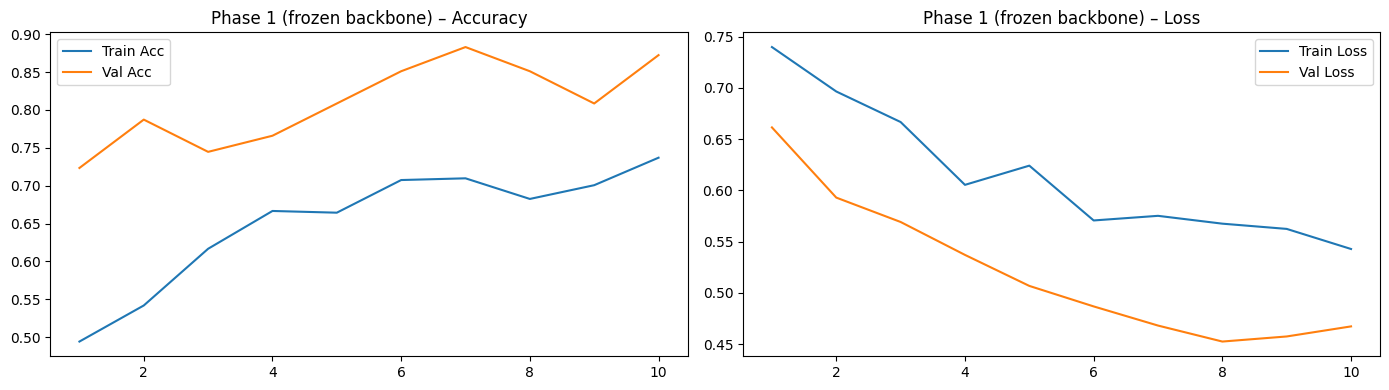

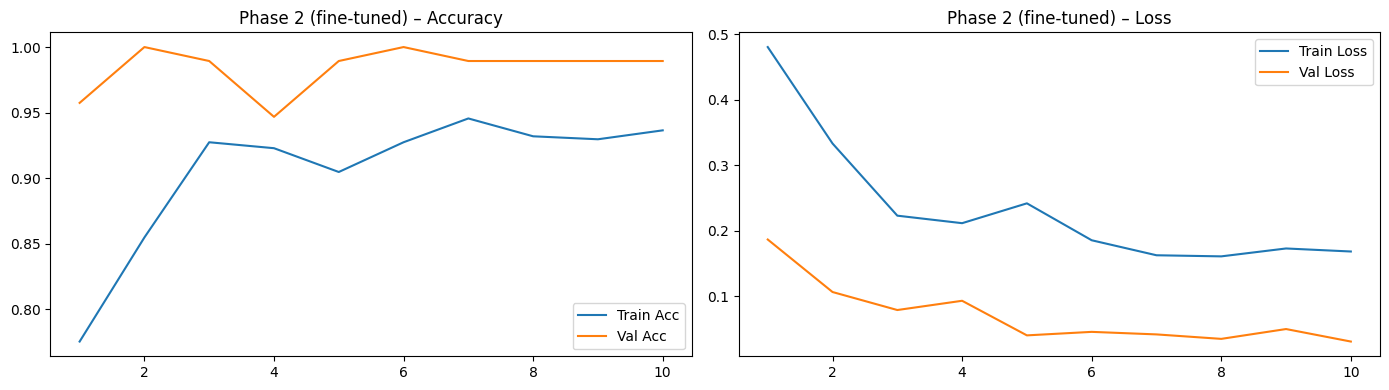

In [20]:
def plot_history(hist, title_prefix="Phase 1"):
    epochs = range(1, len(hist["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(epochs, hist["train_acc"],  label="Train Acc")
    axes[0].plot(epochs, hist["val_acc"],    label="Val Acc")
    axes[0].set_title(f"{title_prefix} – Accuracy"); axes[0].legend()
    axes[1].plot(epochs, hist["train_loss"], label="Train Loss")
    axes[1].plot(epochs, hist["val_loss"],   label="Val Loss")
    axes[1].set_title(f"{title_prefix} – Loss"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history,    "Phase 1 (frozen backbone)")
plot_history(history_ft, "Phase 2 (fine-tuned)")


In [21]:
model.load_state_dict(torch.load(best_ckpt_ft, map_location=DEVICE))
test_loss, test_accuracy, test_precision, test_recall, test_auc = run_epoch(
    model, test_loader, criterion, optimizer=None, device=DEVICE
)

# Collect probabilities and labels for the report / confusion matrix
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        probs = torch.sigmoid(model(xb)).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(yb.numpy().flatten())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs > 0.5).astype(int)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test AUC       : {test_auc:.4f}")

Test Loss      : 0.0758
Test Accuracy  : 1.0000
Test Precision : 1.0000
Test Recall    : 1.0000
Test AUC       : 1.0000


                  precision    recall  f1-score   support

non shop lifters       1.00      1.00      1.00        47
    shop lifters       1.00      1.00      1.00        48

        accuracy                           1.00        95
       macro avg       1.00      1.00      1.00        95
    weighted avg       1.00      1.00      1.00        95



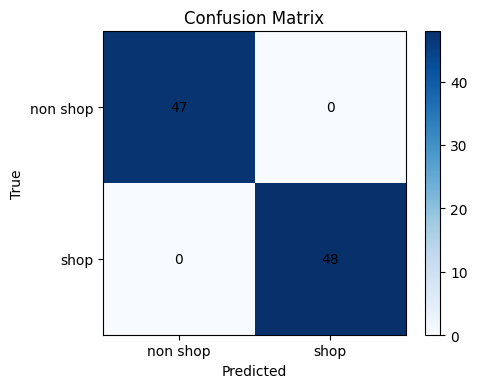

In [22]:
print(classification_report(all_labels.astype(int), all_preds,
                             target_names=["non shop lifters", "shop lifters"]))

cm = confusion_matrix(all_labels.astype(int), all_preds)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["non shop", "shop"])
plt.yticks([0, 1], ["non shop", "shop"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


In [23]:
def predict_single_video(model, video_path, seq_len=16, img_size=112, device=DEVICE):
    model.eval()
    video = preprocess_video(video_path, seq_len=seq_len, img_size=img_size, augment=False)
    x     = torch.tensor(video).unsqueeze(0).to(device)   # (1, C, T, H, W)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()
    label      = 1 if prob > 0.5 else 0
    class_name = "shop lifters" if label == 1 else "non shop lifters"
    return prob, label, class_name

sample_video = test_df.iloc[0]["path"]
prob, label, class_name = predict_single_video(model, sample_video)
print("Video          :", sample_video)
print("Probability    :", f"{prob:.4f}")
print("Predicted label:", label)
print("Predicted class:", class_name)


Video          : /kaggle/working/Shop DataSet/shop lifters/videppppsss_48.mp4
Probability    : 0.9529
Predicted label: 1
Predicted class: shop lifters
